# Notebook 21 — Pillar G: Pantheon+ Type Ia Supernova Distance Moduli

Pantheon+ is the largest published compilation of Type Ia SNe used for cosmology (Scolnic+ 2022, ApJ 938, 113). It contains 1701 SN measurements over $z \in [0.001, 2.26]$, with a full statistical+systematic covariance matrix.

**What this pillar tests.** Distance modulus $\mu(z) = 5\log_{10}[d_L(z)/{\rm Mpc}] + 25$ where $d_L(z) = (1+z)\int_0^z dz'/H(z')$. Different $H(z)$ shapes produce different $\mu(z)$ predictions, so this is an integrated test that is sensitive even when $H(z)$ itself looks featureless (Pillar F).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.integrate import quad
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family':'serif','font.size':10,'figure.dpi':140})

t_P    = 5.391e-44
t_now  = 4.354e17  # 13.8 Gyr in s
C_KMS  = 299792.458

## 1. Load Pantheon+ data and (stat+sys) covariance

In [2]:
# Distance modulus file: 1701 SNe, columns include zHD, MU_SH0ES, MU_SH0ES_ERR_DIAG, IS_CALIBRATOR
tab = np.genfromtxt('data/pantheon_plus_distances.txt', names=True, dtype=None, encoding='ascii')
z_all = tab['zHD'].astype(float)
mu_all = tab['MU_SH0ES'].astype(float)
is_cal = tab['IS_CALIBRATOR'].astype(int).astype(bool)

# Use the cosmology sample (drop calibrators to avoid SH0ES anchor information).
# Following Brout 2022 / Scolnic 2022, restrict to z>0.01 to avoid peculiar-velocity-dominated low-z.
mask = (~is_cal) & (z_all > 0.01)
z = z_all[mask]
mu = mu_all[mask]
idx_kept = np.where(mask)[0]
N = len(z)
print(f'Pantheon+ cosmology sample: N = {N} SNe (out of {len(z_all)} total),  z in [{z.min():.4f}, {z.max():.4f}]')

# Load full 1701x1701 stat+sys covariance and slice to selected SNe
with open('data/pantheon_plus_cov_stat.txt') as f:
    n_full = int(f.readline().strip())
    cov_flat = np.loadtxt(f)
C_full = cov_flat.reshape(n_full, n_full)
C = C_full[np.ix_(idx_kept, idx_kept)]
print(f'Covariance matrix shape: {C.shape}, condition number ~ {np.linalg.cond(C):.2e}')
Cinv = np.linalg.inv(C)


Pantheon+ cosmology sample: N = 1580 SNe (out of 1701 total),  z in [0.0102, 2.2614]


Covariance matrix shape: (1580, 1580), condition number ~ 4.60e+02


## 2. Three competing $H(z)$ models, integrated to $\mu(z)$

In [3]:
def E_LCDM(zp, Om):
    return np.sqrt(Om*(1+zp)**3 + (1-Om))

def H_LCDM(zp, H0, Om):
    return H0 * E_LCDM(zp, Om)

def H_DSC(zp, H_inf, beta_scaled):
    n = (t_now / (1+zp)**1.5) / t_P
    xi_scaled = 1e5 / np.log(n)**2
    return H_inf + beta_scaled * xi_scaled

def mu_from_H(z_arr, H_func, *args):
    # d_L = (1+z) * c * \int_0^z dz' / H(z')
    # Use vectorized cumulative trapezoid for speed.
    z_grid = np.linspace(0, z_arr.max()*1.001, 4000)
    invH = 1.0 / H_func(z_grid, *args)
    chi = np.zeros_like(z_grid)
    chi[1:] = np.cumsum(0.5*(invH[1:]+invH[:-1]) * np.diff(z_grid))
    d_L = (1 + z_arr) * C_KMS * np.interp(z_arr, z_grid, chi)
    return 5*np.log10(d_L) + 25

def chi2_pantheon(model_func, params):
    mu_pred = mu_from_H(z, model_func, *params)
    res = mu - mu_pred
    return float(res @ Cinv @ res)

# Sanity: ΛCDM with Planck cosmology
chi2_planck = chi2_pantheon(H_LCDM, (67.4, 0.315))
print(f'Sanity: ΛCDM Planck-2018 (H0=67.4, Omega_m=0.315) chi^2 = {chi2_planck:.2f}')
print(f'        per dof (1701 SNe -> 1700 dof for one nuisance) ~ {chi2_planck/(N-1):.4f}\n')

Sanity: ΛCDM Planck-2018 (H0=67.4, Omega_m=0.315) chi^2 = 3818.09
        per dof (1701 SNe -> 1700 dof for one nuisance) ~ 2.4180



In [4]:
# Fit ΛCDM (H0, Om) and DSC (H_inf, beta_scaled)
res_lcdm = minimize(lambda p: chi2_pantheon(H_LCDM, p), [70.0, 0.30],
                    bounds=[(50,90),(0.05,0.6)], method='Nelder-Mead', options={'xatol':1e-3, 'fatol':1e-2})
res_dsc  = minimize(lambda p: chi2_pantheon(H_DSC,  p), [70.0, 5.0],
                    bounds=[(0,150),(-200,200)], method='Nelder-Mead', options={'xatol':1e-3, 'fatol':1e-2})

for name, res, k in [('LCDM', res_lcdm, 2), ('DSC', res_dsc, 2)]:
    chi2v = res.fun; dof = N - k
    aic = chi2v + 2*k
    bic = chi2v + k*np.log(N)
    print(f'{name:5s}: chi2 = {chi2v:.2f}, chi2/dof = {chi2v/dof:.3f}, AIC = {aic:.2f}, BIC = {bic:.2f}, params = {res.x}')

delta_aic = res_dsc.fun - res_lcdm.fun  # same k=2 so AIC diff = chi2 diff
delta_bic = delta_aic
print(f'\nΔchi^2 (DSC - LCDM) = {delta_aic:.2f}')
print(f'ΔAIC = ΔBIC = {delta_aic:.2f}  (positive => LCDM preferred)')
print(f'Significance of preference: |Δchi^2|^(1/2) ~ {np.sqrt(abs(delta_aic)):.2f} sigma' if delta_aic>0 else 'DSC preferred')

LCDM : chi2 = 1387.10, chi2/dof = 0.879, AIC = 1391.10, BIC = 1401.83, params = [73.2450156   0.33164172]
DSC  : chi2 = 2004.24, chi2/dof = 1.270, AIC = 2008.24, BIC = 2018.97, params = [ 0.         15.24512145]

Δchi^2 (DSC - LCDM) = 617.14
ΔAIC = ΔBIC = 617.14  (positive => LCDM preferred)
Significance of preference: |Δchi^2|^(1/2) ~ 24.84 sigma


## 3. Hubble diagram + residuals

Saved fig24


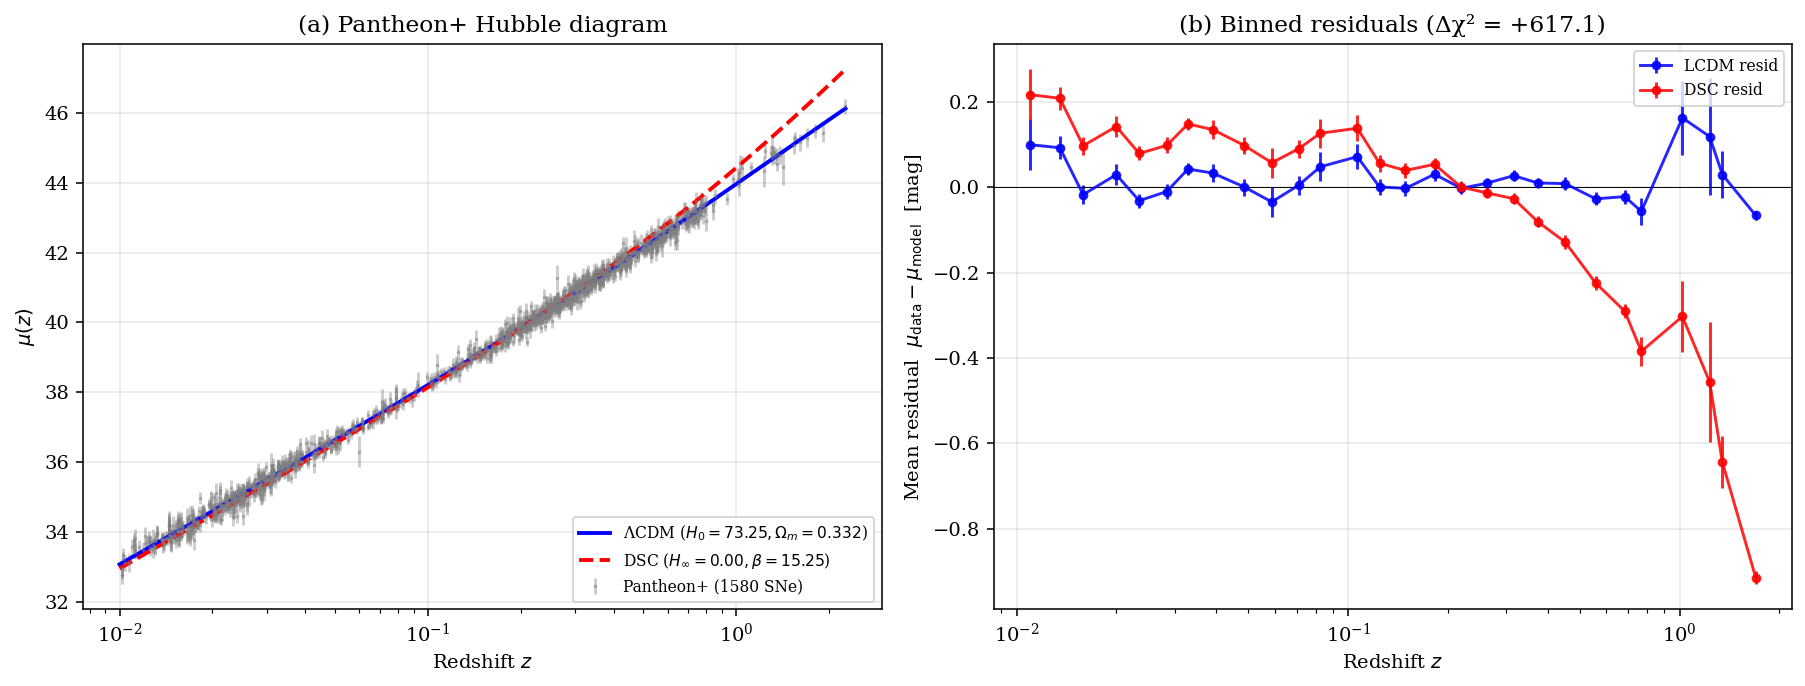

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
z_plot = np.geomspace(0.01, z.max(), 300)
mu_lcdm = mu_from_H(z_plot, H_LCDM, *res_lcdm.x)
mu_dsc  = mu_from_H(z_plot, H_DSC,  *res_dsc.x)

# Hubble diagram
ax[0].errorbar(z, mu, yerr=np.sqrt(np.diag(C)), fmt='.', ms=2, alpha=0.4, color='gray', label=f'Pantheon+ ({N} SNe)')
ax[0].plot(z_plot, mu_lcdm, 'b-', lw=2, label=f'ΛCDM ($H_0={res_lcdm.x[0]:.2f}, \\Omega_m={res_lcdm.x[1]:.3f}$)')
ax[0].plot(z_plot, mu_dsc, 'r--', lw=2, label=f'DSC ($H_\\infty={res_dsc.x[0]:.2f}, \\beta={res_dsc.x[1]:.2f}$)')
ax[0].set_xscale('log'); ax[0].set_xlabel('Redshift $z$'); ax[0].set_ylabel(r'$\mu(z)$')
ax[0].set_title('(a) Pantheon+ Hubble diagram')
ax[0].legend(fontsize=8, loc='lower right'); ax[0].grid(alpha=0.3)

# Residuals: mu_data - mu_LCDM, shown vs z
mu_lcdm_at_data = mu_from_H(z, H_LCDM, *res_lcdm.x)
mu_dsc_at_data  = mu_from_H(z, H_DSC,  *res_dsc.x)
z_bins = np.geomspace(0.01, z.max(), 30)
for label, resid, color in [('LCDM resid', mu - mu_lcdm_at_data, 'b'),
                              ('DSC resid',  mu - mu_dsc_at_data,  'r')]:
    bin_idx = np.digitize(z, z_bins)
    bin_centers, bin_means, bin_errs = [], [], []
    for k in range(1, len(z_bins)):
        sel = bin_idx == k
        if sel.sum() < 3: continue
        bin_centers.append(np.median(z[sel]))
        bin_means.append(np.mean(resid[sel]))
        bin_errs.append(np.std(resid[sel])/np.sqrt(sel.sum()))
    ax[1].errorbar(bin_centers, bin_means, yerr=bin_errs, fmt='-o', ms=4, label=label, color=color, alpha=0.85)
ax[1].axhline(0, color='k', lw=0.5)
ax[1].set_xscale('log'); ax[1].set_xlabel('Redshift $z$'); ax[1].set_ylabel(r'Mean residual  $\mu_{\rm data} - \mu_{\rm model}$  [mag]')
ax[1].set_title(f'(b) Binned residuals (Δχ² = {res_dsc.fun-res_lcdm.fun:+.1f})')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig24_pantheon_pillar_G.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('fig24_pantheon.png', dpi=140, bbox_inches='tight', facecolor='white')
print('Saved fig24')
plt.show()